In [93]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA



In [27]:
data_path = 'smal_synthetic_cluster3.csv'
data = pd.read_csv(data_path)
data.head()


,Feature1,Feature2,Feature3,Feature4
0,3.209829,6.288016,8.779599,3.434792
1,3.469873,6.357605,8.750311,4.640079
2,2.897316,6.983163,7.984679,5.178400
3,5.025017,10.319797,8.751064,3.756091
4,4.890931,6.652193,6.971111,4.561892


In [5]:
data.describe()

,Feature1,Feature2,Feature3,Feature4
count,1100.000000,1100.000000,1100.000000,1100.000000
mean,1.510687,2.455905,-0.546300,0.533638
std,2.463529,4.024761,6.456701,3.170233
min,-4.325953,-8.070381,-11.480635,-4.423803
25%,-0.291416,-0.347744,-7.436226,-2.734794
50%,1.328288,1.626122,1.186511,0.928707
75%,3.273311,5.300057,6.066833,3.162853
max,9.899829,13.530499,10.863002,9.893624


array([[<Axes: title={'center': 'Feature1'}>,
        <Axes: title={'center': 'Feature2'}>],
       [<Axes: title={'center': 'Feature3'}>,
        <Axes: title={'center': 'Feature4'}>]], dtype=object)

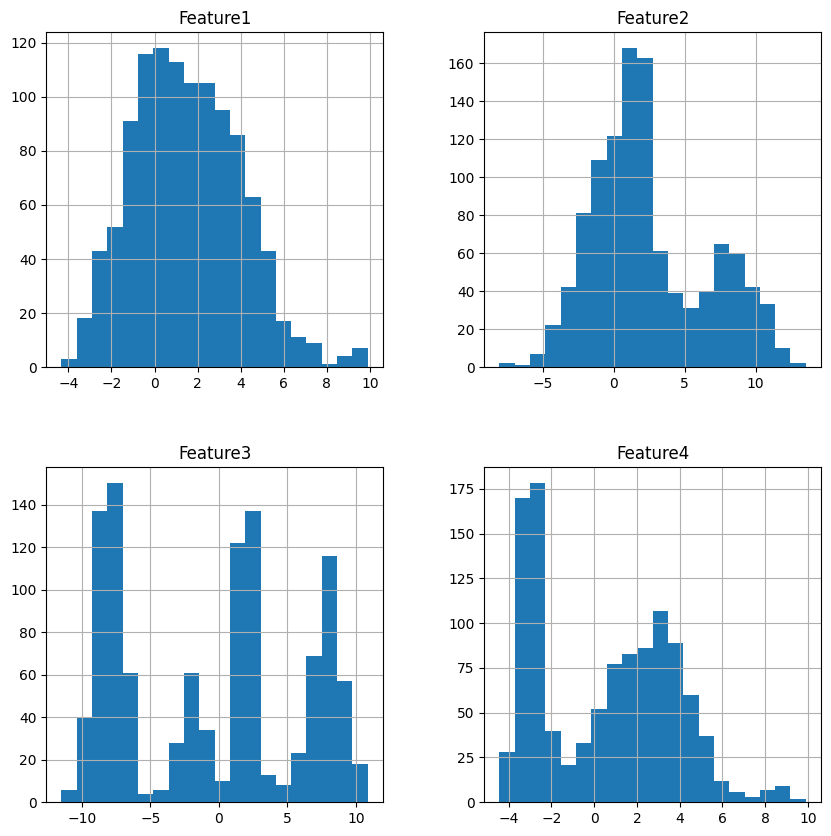

In [18]:
data.hist(bins=20, figsize=(10,10))

## Plotting 2d feature by feature par

We would guess that 2 clusters looks right!

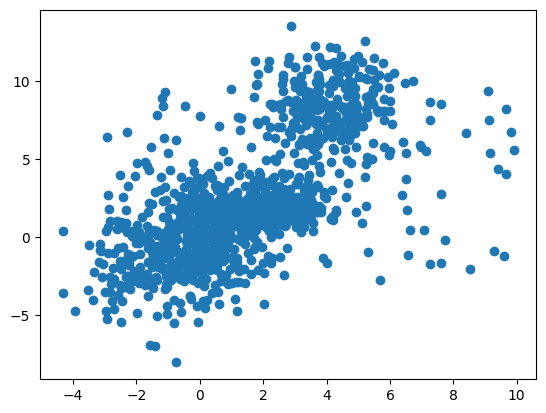

In [19]:
plt.scatter(data["Feature1"], data["Feature2"])

In [38]:
data[["Feature1", "Feature2"]]

,Feature1,Feature2
0,3.209829,6.288016
1,3.469873,6.357605
2,2.897316,6.983163
3,5.025017,10.319797
4,4.890931,6.652193
...,...,...
1095,-1.334291,7.869570
1096,-1.586234,4.335681
1097,9.661348,4.047703
1098,3.092516,3.435682


In [66]:
km_f1_f2 = KMeans(n_clusters=2)
km_f1_f2.fit(data[["Feature1", "Feature2"]])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [67]:
km_f1_f2.cluster_centers_

array([[4.06509859, 8.02106979],
       [0.54397984, 0.34978962]])

In [68]:
km_f1_f2.labels_

array([0, 0, 0, ..., 0, 1, 1], shape=(1100,), dtype=int32)

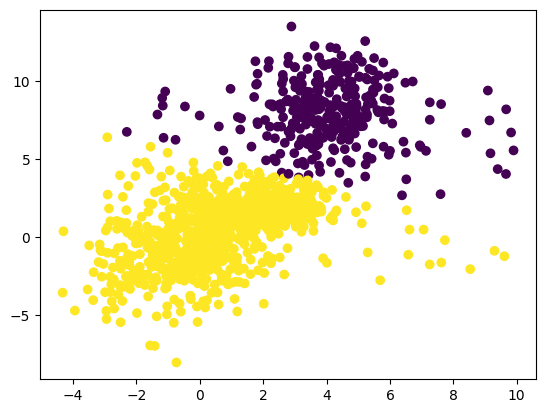

In [69]:
plt.scatter(data["Feature1"], data["Feature2"], c=km_f1_f2.labels_)

For some reason, 4 looks okey here? Why?

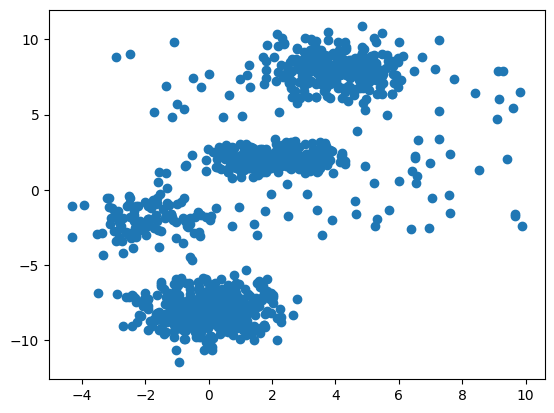

In [20]:
plt.scatter(data["Feature1"], data["Feature3"])

In [70]:
km_f1_f3 = KMeans(n_clusters=4)
km_f1_f3.fit(data[["Feature1", "Feature3"]])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


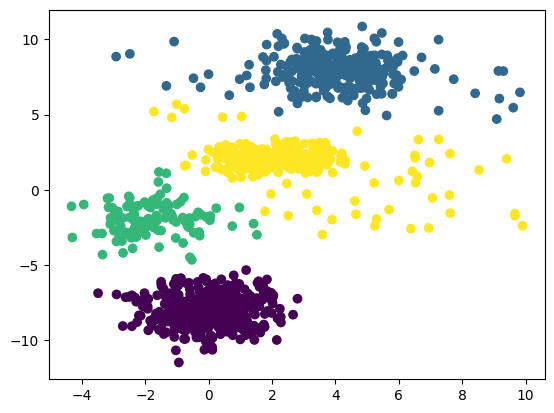

In [71]:
plt.scatter(data["Feature1"], data["Feature3"], c=km_f1_f3.labels_)

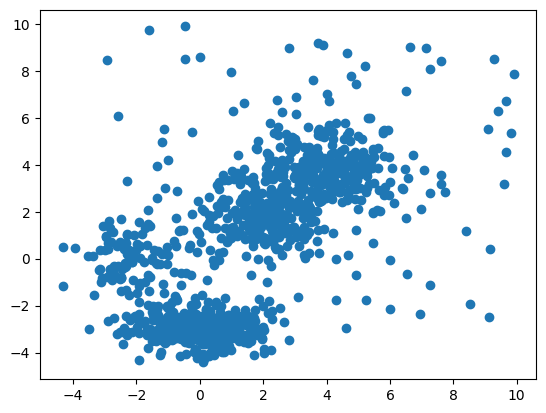

In [21]:
plt.scatter(data["Feature1"], data["Feature4"])

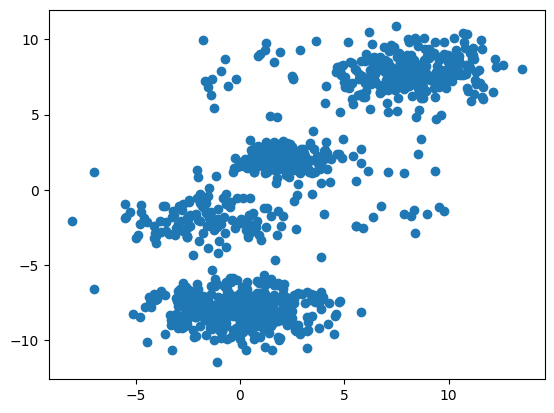

In [23]:
plt.scatter(data["Feature2"], data["Feature3"])

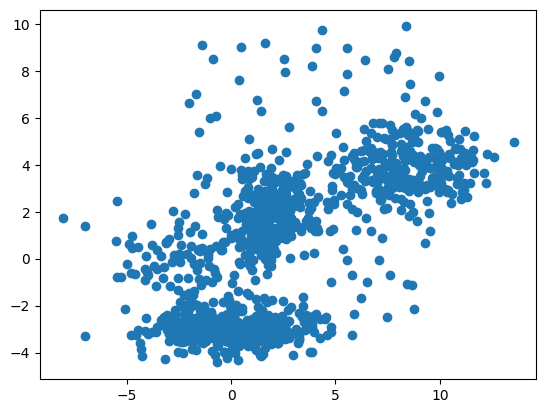

In [24]:
plt.scatter(data["Feature2"], data["Feature4"])

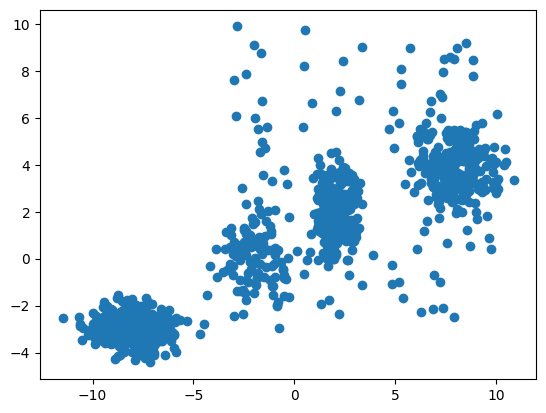

In [25]:
plt.scatter(data["Feature3"], data["Feature4"])

In [6]:
df = data.dropna()

## Lets try kmeans on all data?

In [86]:
km_all = KMeans(n_clusters=4)
km_all.fit(data)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [87]:
km_all.inertia_

10657.20417643182

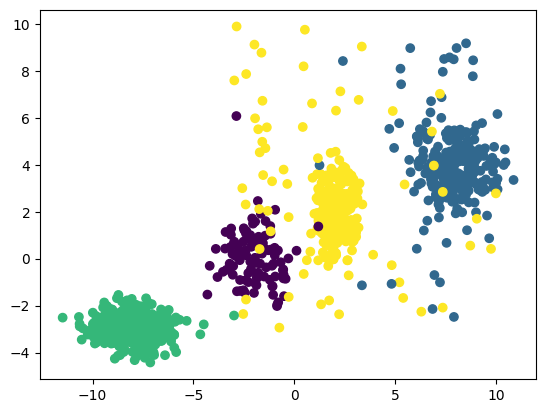

In [88]:
plt.scatter(data["Feature3"], data["Feature4"], c=km_all.labels_)

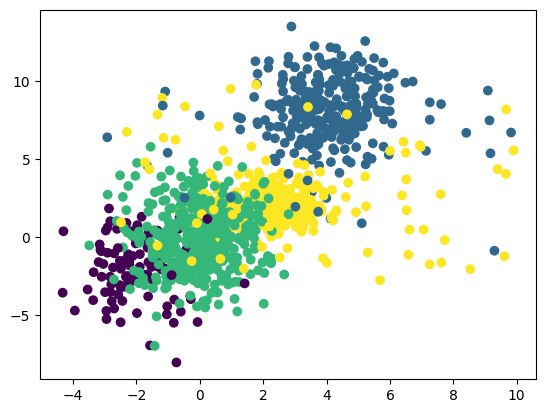

In [89]:
plt.scatter(data["Feature1"], data["Feature2"], c=km_all.labels_)

## Elbow method!!

In [82]:
list_of_inertia = []

for k in range(1,21):
    km_all = KMeans(n_clusters=k)
    km_all.fit(data)
    list_of_inertia.append(km_all.inertia_)

print(list_of_inertia)

[81333.73936788933, 26211.87751209127, 14679.27522453733, 10657.20417643182, 9616.148910069856, 8901.618061455723, 7859.9742621910655, 7535.609424395049, 7320.6516424902475, 6692.928014469787, 6401.185102767773, 6470.143179183251, 6454.603914947154, 5608.371440895649, 5519.719540668405, 5353.254512429033, 5335.347160093592, 4990.720123322486, 4953.502540565981, 4695.18691303786]


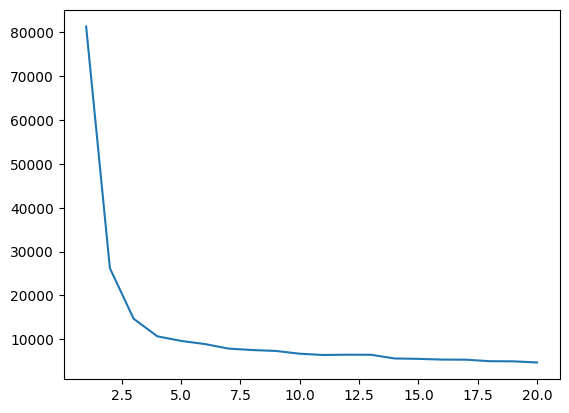

In [ ]:
plt.plot(range(1,21), list_of_inertia)

Given the elbow curve above we think that 4 is the optimal number of clusters!

In [92]:
km_all.predict([[-1,2,-1,4]])

c:\Users\Sebastian\Systementor\TH_PYAI25\IntroMachineleraning\Lektioner_IntroML_TH_PYAI25\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([3], dtype=int32)

In [94]:
def pca_transformation(data):
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(data)
    principal_df = pd.DataFrame(data = principal_components
             ,columns = ['principal component 1', 'principal component 2'])
    return principal_df

In [95]:
data_pca = pca_transformation(data)

In [ ]:
data_pca

,principal component 1,principal component 2
0,10.515595,-0.808920
1,11.011845,-0.971840
2,10.722935,-0.373241
3,12.718606,2.963944
4,10.005806,0.310698
...,...,...
1095,3.678988,2.909066
1096,4.239065,-1.662545
1097,3.918697,1.987485
1098,0.214563,1.578194


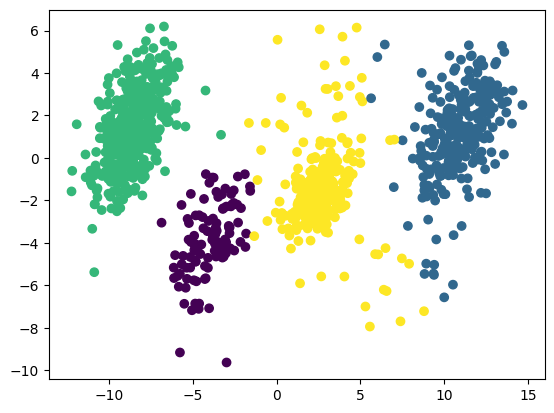

In [99]:
plt.scatter(data_pca["principal component 1"], data_pca["principal component 2"], c=km_all.labels_)

## 3D exempel för matplotlib

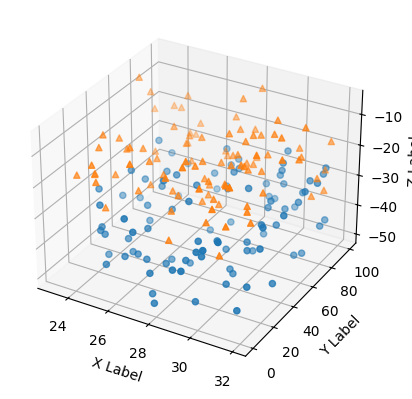

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(19680801)


def randrange(n, vmin, vmax):
    """
    Helper function to make an array of random numbers having shape (n, )
    with each number distributed Uniform(vmin, vmax).
    """
    return (vmax - vmin)*np.random.rand(n) + vmin

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

n = 100

# For each set of style and range settings, plot n random points in the box
# defined by x in [23, 32], y in [0, 100], z in [zlow, zhigh].
for m, zlow, zhigh in [('o', -50, -25), ('^', -30, -5)]:
    xs = randrange(n, 23, 32)
    ys = randrange(n, 0, 100)
    zs = randrange(n, zlow, zhigh)
    ax.scatter(xs, ys, zs, marker=m)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

plt.show()

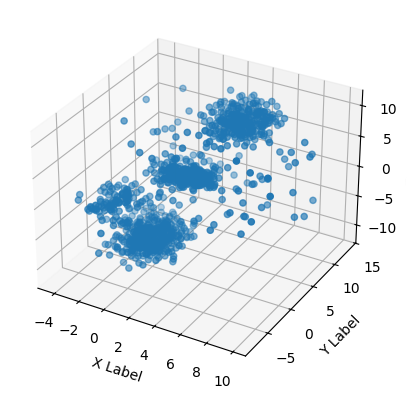

In [8]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

n = 100

ax.scatter(df['Feature1'], df['Feature2'], df['Feature3'])

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

plt.show()

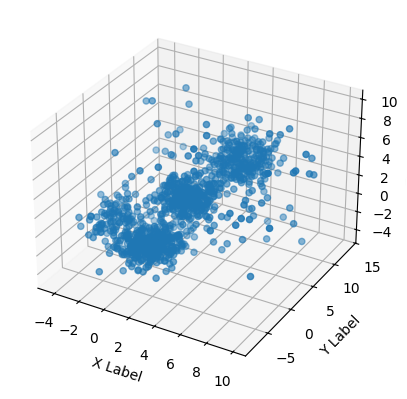

In [9]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')


ax.scatter(df['Feature1'], df['Feature2'], df['Feature4'])

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

plt.show()

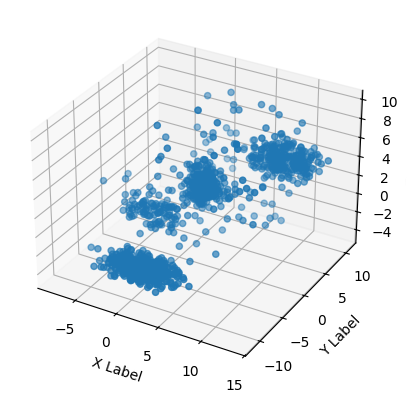

In [10]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')


ax.scatter(df['Feature2'], df['Feature3'], df['Feature4'])

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

plt.show()

In [ ]:


kmeans = KMeans(n_clusters=1, random_state=42, n_init='auto').fit(df)
max_inertia = kmeans.inertia_
# kmeans.labels_
# kmeans.inertia_

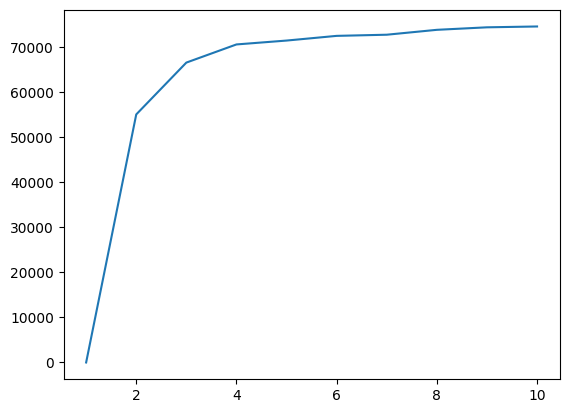

In [12]:
lbow = []
lbow2 = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto').fit(df)
    lbow.append(max_inertia - kmeans.inertia_)
    lbow2.append(kmeans.inertia_)

plt.plot([i for i in range(1,11)], lbow)
    

In [13]:
for i in range(1, len(lbow2)-1):
    print((lbow2[i-1]-lbow2[i])/lbow2[i-1])

0.6777244263474778
0.4395400004087967
0.27454640555077714
0.08088917613724633
0.10644946516414915
0.029254522188109616
0.1279831693100386
0.07510467341022417
